# Program Starter

In [ ]:
import json
from pathlib import Path
import pandas as pd
import yfinance as yf
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [2]:
START_DATE = "2006-01-01"  
END_DATE = "2025-12-31"
INTERVAL = "1mo"

BASE = Path("data")
BASE.mkdir(exist_ok=True)

MARKET_FILE = Path("markets.json")

RF_FILE    = BASE / "risk_free_monthly.csv"
FRED_URL   = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=TB3MS"
FRED_LOCAL = BASE / "tb3ms_raw.csv"   # raw FRED download

In [3]:
def load_markets(path: Path = MARKET_FILE) -> dict:
    with open(path, "r") as f:
        config = json.load(f)

    markets = config["markets"]

    print(f"Initial investment : ${config['initial_investment']:,}")
    print(f"Monthly investment : ${config['monthly_investment']:,}")
    print(f"Markets loaded     : {len(markets)}")
    
    for name, tickers in markets.items():
        print(f"  {name}: {tickers}")

    return config
    

In [4]:
config = load_markets()
markets = config["markets"]


Initial investment : $1,000
Monthly investment : $100
Markets loaded     : 1
  primary_total_market: ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']


In [5]:
def formulate_monthly_prices(tickers, start, end, interval) -> pd.DataFrame:
    if isinstance(tickers, str):
        tickers = [tickers]

    data = yf.download(
        tickers,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=True,
        progress=False,
    )

    # Single ticker  → flat columns (Price, Date)
    # Multiple tickers → MultiIndex (Price Level, Ticker)
    if isinstance(data.columns, pd.MultiIndex):
        price_level = (
            "Close" if "Close" in data.columns.get_level_values(0)
            else "Adj Close"
        )
        data = data[price_level]
    else:
        price_col = "Close" if "Close" in data.columns else "Adj Close"
        data = data[[price_col]]
        data.columns = tickers

    if isinstance(data, pd.Series):
        data = data.to_frame(name=tickers[0])

    return data.dropna(how="all")

In [6]:
formulate_monthly_prices("AAPL", START_DATE, END_DATE, INTERVAL)

Ticker,AAPL
Date,
2006-01-01,2.262507
2006-02-01,2.052166
2006-03-01,1.879279
2006-04-01,2.109095
2006-05-01,1.790890
...,...
2025-08-01,231.435715
2025-09-01,254.145599
2025-10-01,269.855652


In [ ]:
# Saves prices and recomputes returns for a named market.

def update_monthly_dataset(name, tickers):
    price_file = BASE / f"{name}_prices_monthly.csv"
    returns_file = BASE / f"{name}_returns_monthly.csv"

    if not price_file.exists():
        print(f"[NEW] Creating dataset for {name}")
        data = formulate_monthly_prices(tickers, START_DATE, END_DATE, INTERVAL)
    else:
        print(f"[UPDATE] Updating dataset for {name}")

        existing = pd.read_csv(price_file, index_col=0, parse_dates=True)
        last_date = existing.index.max()

        # Start from next month to avoid overlap
        start_ts = last_date + pd.offsets.MonthBegin(1)
        end_ts = pd.to_datetime(END_DATE)

        if start_ts > end_ts:
            print(f"[OK]     {name} — already up to date ({last_date.date()})")
            data = existing
        else:
            print(f"[UPDATE] {name} — fetching {start_ts.date()} → {END_DATE}")
            new_data = formulate_monthly_prices(
                tickers,
                start_ts.strftime("%Y-%m-%d"), 
                END_DATE, 
                INTERVAL
                )
            data = pd.concat([existing, new_data])
            data = data[~data.index.duplicated(keep="last")].sort_index()

    # Ensure all tickers exist
    missing = [t for t in tickers if t not in data.columns]
    if missing:
        raise ValueError(f"{name} -> Missing tickers: {missing}")

    # Clean rows where any asset missing
    data = data[tickers]    
    data = data.dropna()

    
    nan_counts = data.isnull().sum()
    if nan_counts.any():
        print(f"  ⚠️  NaNs remaining after dropna: {nan_counts[nan_counts > 0].to_dict()}")

    # Save prices
    data.to_csv(price_file)

    # Recompute returns every time
    rets = data.pct_change().dropna()           # (latest-old)/old -> decimal rets
    rets.to_csv(returns_file)

    print(f"         → {len(data)} months  |  {data.index.min().date()} → {data.index.max().date()}")
    print(f"         → prices  : {price_file}")
    print(f"         → returns : {returns_file}")

    return {
        "name"         : name,
        "tickers"      : tickers,
        "months"       : len(data),
        "return_rows"  : len(rets),
        "start"        : data.index.min(),
        "end"          : data.index.max(),
        "price_file"   : price_file,
        "returns_file" : returns_file,
        "data"         : data,
        "rets"         : rets,
    }


In [8]:
results = {}
for name, tickers in markets.items():
    results[name] = update_monthly_dataset(name, tickers)

print("\n Pipelines completed for all markets.\n")

[UPDATE] Updating dataset for primary_total_market
[OK]     primary_total_market — already up to date (2025-12-01)
         → 225 months  |  2007-04-01 → 2025-12-01
         → prices  : data\primary_total_market_prices_monthly.csv
         → returns : data\primary_total_market_returns_monthly.csv

 Pipelines completed for all markets.



## Risk Free Rate 

robo advisors reference the current short term treasury rate. this can be found in FRED.
goes from 0 in 2010/15 to 5% in 2022/23

In [9]:
# ── Cell 8: Rolling Risk-Free Rate — Direct from FRED ────────────────────────
#
# WHY 3-MONTH T-BILLS?
# The risk-free rate needs two properties:
#   1. Zero default risk  — US government guaranteed
#   2. Near-zero duration risk — matures in 90 days, so rising rates don't
#      hurt its value the way a 10-year bond would in 2022
# The 3-month T-bill (FRED series TB3MS) is the standard used by Markowitz,
# Sharpe, and every major robo-advisor platform.
#
# WHY FRED DIRECTLY INSTEAD OF ^IRX?
# ^IRX via Yahoo Finance frequently lags or has gaps near the current date.
# FRED's TB3MS is the official monthly series, updated through the present
# month, and accessible via a simple public URL — no API key needed.
#
# URL format:
#   https://fred.stlouisfed.org/graph/fredgraph.csv?id=TB3MS

def fetch_from_fred() -> pd.DataFrame:
    """
    Download TB3MS directly from FRED as a CSV.
    Returns monthly DataFrame with rf_annual and rf_monthly columns.
    Rate floor of 0.01% annual applied to avoid optimizer issues near zero.
    """
    print("Downloading TB3MS from FRED...")
    urllib.request.urlretrieve(FRED_URL, FRED_LOCAL)

    raw = pd.read_csv(FRED_LOCAL, index_col=0, parse_dates=True)
    raw.columns = ["rate_pct"]

    # FRED gives annual rate in percent (e.g. 5.25 means 5.25% per year)
    # Convert to decimal and apply floor
    rf_annual  = (raw["rate_pct"] / 100).clip(lower=0.0001)

    # Resample to monthly — FRED TB3MS is already monthly but use last() to be safe
    rf_annual  = rf_annual.resample("MS").last().dropna()

    # Filter to project date range
    rf_annual  = rf_annual.loc[START_DATE:END_DATE]

    rf_monthly = (1 + rf_annual) ** (1/12) - 1

    result = pd.DataFrame({
        "rf_annual"  : rf_annual.values,
        "rf_monthly" : rf_monthly.values,
    }, index=rf_annual.index)

    result.index.name = "Date"
    return result


def update_risk_free_rate() -> pd.DataFrame:
    """
    Always re-pull from FRED to get the latest data through END_DATE.
    FRED is fast (~1 second) so there is no cost to refreshing every run.
    """
    rf = fetch_from_fred()

    # Check coverage
    latest = rf.index.max()
    target = pd.to_datetime(END_DATE)
    if latest < target - pd.DateOffset(months=3):
        print(f"  WARNING: FRED data ends at {latest.date()} — "
              f"may be missing recent months. Check FRED for TB3MS updates.")
    else:
        print(f"  Coverage OK: {rf.index.min().date()} → {latest.date()}")

    rf.to_csv(RF_FILE)
    print(f"  Months  : {len(rf)}")
    print(f"  Saved   : {RF_FILE}")
    return rf


rf_data = update_risk_free_rate()

print()
print("── Risk-Free Rate by Period ──")
checkpoints = {
    "2008-09 (GFC peak)"      : "2008-09",
    "2010-01 (post-GFC low)"  : "2010-01",
    "2015-01 (zero-rate era)" : "2015-01",
    "2019-01 (pre-COVID)"     : "2019-01",
    "2022-06 (rate hikes)"    : "2022-06",
    "2023-06 (peak rate)"     : "2023-06",
}
for label, d in checkpoints.items():
    matches = rf_data.loc[d:d]
    if not matches.empty:
        row = matches.iloc[0]
        print(f"  {label:<30} {row['rf_annual']*100:.2f}% annual")
    else:
        print(f"  {label:<30} no data")


  Coverage OK: 2006-01-01 → 2025-12-01
  Months  : 240
  Saved   : data\risk_free_monthly.csv

── Risk-Free Rate by Period ──
  2008-09 (GFC peak)             1.13% annual
  2010-01 (post-GFC low)         0.06% annual
  2015-01 (zero-rate era)        0.03% annual
  2019-01 (pre-COVID)            2.37% annual
  2022-06 (rate hikes)           1.49% annual
  2023-06 (peak rate)            5.16% annual


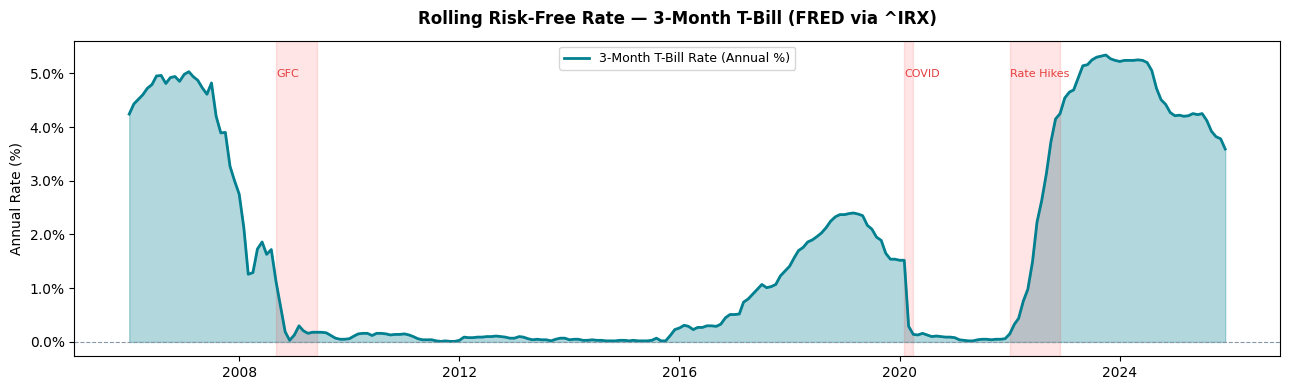

Min rate : 0.010%  (2011-09-01)
Max rate : 5.340%  (2023-10-01)
Avg rate : 1.640%

File saved: data\risk_free_monthly.csv
All strategy notebooks can now load this file instead of using a fixed rate.


In [ ]:
# ── Cell 9: Risk-Free Rate Verification Plot ──────────────────────────────────
CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(rf_data.index, rf_data["rf_annual"] * 100,
                alpha=0.3, color="#028090")
ax.plot(rf_data["rf_annual"] * 100, color="#028090",
        linewidth=2, label="3-Month T-Bill Rate (Annual %)")

for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.10, color="red")
ymax = ax.get_ylim()[1]
for start, _, label in CRISES:
    ax.text(pd.Timestamp(start), ymax * 0.88,
            label, fontsize=8, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Rolling Risk-Free Rate — 3-Month T-Bill (FRED via TB3MS)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Annual Rate (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Min rate : {rf_data['rf_annual'].min()*100:.3f}%  ({rf_data['rf_annual'].idxmin().date()})")
print(f"Max rate : {rf_data['rf_annual'].max()*100:.3f}%  ({rf_data['rf_annual'].idxmax().date()})")
print(f"Avg rate : {rf_data['rf_annual'].mean()*100:.3f}%")
print()
print(f"File saved: {RF_FILE}")
print("All strategy notebooks can now load this file instead of using a fixed rate.")


In [11]:
# ── Cell 7: Verification Summary ─────────────────────────────────────────────
# Spot-check every market: shape, date range, NaN counts, return sanity.

print("═" * 65)
print(f"{'VERIFICATION SUMMARY':^65}")
print("═" * 65)

for name, r in results.items():
    data = r["data"]
    rets = r["rets"]

    print(f"\n▸ {name}")
    print(f"  Tickers   : {r['tickers']}")
    print(f"  Price rows: {r['months']}  \nReturn rows: {r['return_rows']}")
    print(f"  Date range: {r['start'].date()} → {r['end'].date()}")

    # NaN check
    nan_p = data.isnull().sum().sum()
    nan_r = rets.isnull().sum().sum()
    print(f"  NaNs      : prices={nan_p}  returns={nan_r}  {'✓' if nan_p+nan_r == 0 else '⚠️ CHECK'}")

    # Return sanity — flag any monthly return beyond ±60% (likely data error)
    extreme = (rets.abs() > 0.60)
    if extreme.any().any():
        flagged = rets[extreme.any(axis=1)]
        print(f"  ⚠️  Extreme returns (>±60%) detected:")
        print(flagged)
    else:
        print(f"  Returns   : no extreme values detected  ✓")

    # Annualized stats preview
    ann_ret = rets.mean() * 12 * 100
    ann_vol = rets.std() * (12 ** 0.5) * 100
    print(f"  Ann. Return (%) :")
    print("    " + "  ".join(f"{c}: {v:.1f}" for c, v in ann_ret.items()))
    print(f"  Ann. Vol (%)    :")
    print("    " + "  ".join(f"{c}: {v:.1f}" for c, v in ann_vol.items()))

print("\n" + "═" * 65)

═════════════════════════════════════════════════════════════════
                      VERIFICATION SUMMARY                       
═════════════════════════════════════════════════════════════════

▸ primary_total_market
  Tickers   : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
  Price rows: 225  
Return rows: 224
  Date range: 2007-04-01 → 2025-12-01
  NaNs      : prices=0  returns=0  ✓
  Returns   : no extreme values detected  ✓
  Ann. Return (%) :
    BND: 3.1  GLD: 11.0  TIP: 3.5  TLT: 4.0  VEU: 6.0  VGT: 16.9
  Ann. Vol (%)    :
    BND: 4.7  GLD: 17.0  TIP: 6.0  TLT: 14.3  VEU: 18.0  VGT: 19.7

═════════════════════════════════════════════════════════════════
